In [5]:
# IMPORT LIBRARIES
# ========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")
plt.style.use("default")

In [6]:
# LOAD DATA
# =========================

df = pd.read_csv('QVI_data.csv')

df["DATE"] = pd.to_datetime(df["DATE"], errors="coerce")
df.shape
df.head()
df.columns.tolist()

['LYLTY_CARD_NBR',
 'DATE',
 'STORE_NBR',
 'TXN_ID',
 'PROD_NBR',
 'PROD_NAME',
 'PROD_QTY',
 'TOT_SALES',
 'PACK_SIZE',
 'BRAND',
 'LIFESTAGE',
 'PREMIUM_CUSTOMER']

In [7]:
# 3) BASIC DATA CHECKS
# =========================
print("Missing values:\n", df.isna().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nData types:\n", df.dtypes)

Missing values:
 LYLTY_CARD_NBR      0
DATE                0
STORE_NBR           0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
PACK_SIZE           0
BRAND               0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

Duplicates: 1

Data types:
 LYLTY_CARD_NBR               int64
DATE                datetime64[us]
STORE_NBR                    int64
TXN_ID                       int64
PROD_NBR                     int64
PROD_NAME                      str
PROD_QTY                     int64
TOT_SALES                  float64
PACK_SIZE                    int64
BRAND                          str
LIFESTAGE                      str
PREMIUM_CUSTOMER               str
dtype: object


In [8]:
# 4) CREATE MONTH COLUMN
# =========================
df["MONTH"] = df["DATE"].dt.to_period("M").dt.to_timestamp()
df.head()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER,MONTH
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium,2018-10-01
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream,2018-09-01
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget,2019-03-01
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget,2019-03-01
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream,2018-11-01


In [9]:
# BUILD MONTHLY STORE METRICS
#    - total sales revenue
#    - total customers
#    - total transactions
#    - average transactions per customer
# =========================
monthly = df.groupby(["STORE_NBR", "MONTH"]).agg(
    total_sales=("TOT_SALES", "sum"),
    total_customers=("LYLTY_CARD_NBR", "nunique"),
    total_transactions=("TXN_ID", "nunique")
).reset_index()

monthly["avg_transactions_per_customer"] = (
    monthly["total_transactions"] / monthly["total_customers"]
)

monthly.head()

,STORE_NBR,MONTH,total_sales,total_customers,total_transactions,avg_transactions_per_customer
0,1,2018-07-01,206.9,49,52,1.061224
1,1,2018-08-01,176.1,42,43,1.023810
2,1,2018-09-01,278.8,59,62,1.050847
3,1,2018-10-01,188.1,44,45,1.022727
4,1,2018-11-01,192.6,46,47,1.021739


In [10]:
# 6) DEFINE TRIAL STORES AND PERIODS
# =========================
trial_stores = [77, 86, 88]

# Quantium trial period used commonly in this project:
# pre-trial = Feb 2018 to Jan 2019
# trial     = Feb 2019 to Apr 2019
pre_trial_start = pd.Timestamp("2018-02-01")
pre_trial_end   = pd.Timestamp("2019-01-31")
trial_start     = pd.Timestamp("2019-02-01")
trial_end       = pd.Timestamp("2019-04-30")

pre_trial = monthly[(monthly["MONTH"] >= pre_trial_start) & (monthly["MONTH"] <= pre_trial_end)].copy()
trial_period = monthly[(monthly["MONTH"] >= trial_start) & (monthly["MONTH"] <= trial_end)].copy()

print("Pre-trial rows:", pre_trial.shape[0])
print("Trial rows:", trial_period.shape[0])

Pre-trial rows: 1848
Trial rows: 794


In [20]:
import os

def plot_trial_vs_control(comp, trial_store, control_store, save_dir="outputs/figures"):
    """Plot sales, customers, and transactions per customer, then save the figure."""
    os.makedirs(save_dir, exist_ok=True)

    fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)

    axes[0].plot(comp["MONTH"], comp["trial_sales"], marker="o", label=f"Trial Store {trial_store}")
    axes[0].plot(comp["MONTH"], comp["control_sales"], marker="o", label=f"Control Store {control_store}")
    axes[0].set_title(f"Monthly Sales: Trial Store {trial_store} vs Control Store {control_store}")
    axes[0].set_ylabel("Sales")
    axes[0].legend()

    axes[1].plot(comp["MONTH"], comp["trial_customers"], marker="o", label=f"Trial Store {trial_store}")
    axes[1].plot(comp["MONTH"], comp["control_customers"], marker="o", label=f"Control Store {control_store}")
    axes[1].set_title("Monthly Customers")
    axes[1].set_ylabel("Customers")
    axes[1].legend()

    axes[2].plot(comp["MONTH"], comp["trial_avg_txn_per_customer"], marker="o", label=f"Trial Store {trial_store}")
    axes[2].plot(comp["MONTH"], comp["control_avg_txn_per_customer"], marker="o", label=f"Control Store {control_store}")
    axes[2].set_title("Average Transactions per Customer")
    axes[2].set_ylabel("Transactions / Customer")
    axes[2].set_xlabel("Month")
    axes[2].legend()

    plt.tight_layout()

    filename = f"store_{trial_store}_vs_control_{control_store}.png"
    plt.savefig(os.path.join(save_dir, filename), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

In [21]:
# 8) SELECT CONTROL STORES FOR ALL 3 TRIAL STORES
#    Exclude the other trial stores from being used as controls
# =========================
control_map = {}
control_rankings = {}

for trial_store in trial_stores:
    control_store, ranking_df = choose_control_store(
        trial_store=trial_store,
        pre_data=pre_trial,
        trial_stores_to_exclude=trial_stores
    )
    control_map[trial_store] = control_store
    control_rankings[trial_store] = ranking_df

    print(f"Trial store {trial_store} -> Control store {control_store}")
    print(ranking_df.head(10)[["trial_store", "candidate_store", "avg_corr", "avg_distance", "score"]])
    print("-" * 80)

Trial store 77 -> Control store 233
   trial_store  candidate_store  avg_corr  avg_distance     score
0           77              233  0.465983      0.042603  0.423380
1           77               17  0.671074      0.252306  0.418768
2           77              145  0.570937      0.155100  0.415838
3           77              115  0.570638      0.157990  0.412647
4           77              167  0.479402      0.123685  0.355718
5           77              176  0.442882      0.118449  0.324434
6           77              111  0.392199      0.098269  0.293930
7           77               84  0.646476      0.370765  0.275711
8           77               41  0.370769      0.096268  0.274501
9           77               20  0.394221      0.123769  0.270452
--------------------------------------------------------------------------------
Trial store 86 -> Control store 138
   trial_store  candidate_store  avg_corr  avg_distance     score
0           86              138  0.684236      0.060052

In [22]:
# COMPARE EACH TRIAL STORE WITH ITS CONTROL STORE
# =========================
all_results = []
all_comp_tables = {}

for trial_store in trial_stores:
    control_store = control_map[trial_store]
    comp = compare_trial_and_control(trial_store, control_store, df, start=trial_start, end=trial_end)
    all_comp_tables[trial_store] = comp

    # Add paired t-tests
    sales_t, sales_p = paired_ttest(comp, "trial_sales", "control_sales")
    cust_t, cust_p = paired_ttest(comp, "trial_customers", "control_customers")
    txn_t, txn_p = paired_ttest(comp, "trial_avg_txn_per_customer", "control_avg_txn_per_customer")

    summary = {
        "trial_store": trial_store,
        "control_store": control_store,
        "trial_avg_sales": comp["trial_sales"].mean(),
        "control_avg_sales": comp["control_sales"].mean(),
        "sales_lift_pct_avg": ((comp["trial_sales"].mean() - comp["control_sales"].mean()) / comp["control_sales"].mean()) * 100,
        "trial_avg_customers": comp["trial_customers"].mean(),
        "control_avg_customers": comp["control_customers"].mean(),
        "customers_lift_pct_avg": ((comp["trial_customers"].mean() - comp["control_customers"].mean()) / comp["control_customers"].mean()) * 100,
        "trial_avg_txn_per_customer": comp["trial_avg_txn_per_customer"].mean(),
        "control_avg_txn_per_customer": comp["control_avg_txn_per_customer"].mean(),
        "txn_per_customer_lift_pct_avg": ((comp["trial_avg_txn_per_customer"].mean() - comp["control_avg_txn_per_customer"].mean()) / comp["control_avg_txn_per_customer"].mean()) * 100,
        "sales_t_stat": sales_t,
        "sales_p_value": sales_p,
        "customers_t_stat": cust_t,
        "customers_p_value": cust_p,
        "txn_per_customer_t_stat": txn_t,
        "txn_per_customer_p_value": txn_p
    }
    all_results.append(summary)

results_df = pd.DataFrame(all_results)
results_df

,trial_store,control_store,trial_avg_sales,control_avg_sales,sales_lift_pct_avg,trial_avg_customers,control_avg_customers,customers_lift_pct_avg,trial_avg_txn_per_customer,control_avg_txn_per_customer,txn_per_customer_lift_pct_avg,sales_t_stat,sales_p_value,customers_t_stat,customers_p_value,txn_per_customer_t_stat,txn_per_customer_p_value
0,77,233,259.000000,200.566667,29.134120,47.333333,38.333333,23.478261,1.040426,1.045370,-0.473023,1.693186,0.232498,1.824491,0.209634,-0.123703,0.912861
1,86,138,929.400000,841.133333,10.493778,109.000000,100.666667,8.278146,1.235704,1.247589,-0.952674,2.029737,0.179516,1.600461,0.250637,-0.291833,0.797901
2,88,178,1428.933333,1049.133333,36.201309,128.666667,112.666667,14.201183,1.253563,1.291494,-2.936996,6.678496,0.021693,6.047432,0.026271,-0.909473,0.459101


In [24]:
# DISPLAY MONTHLY COMPARISON TABLES
# =========================
for trial_store in trial_stores:
    print(f"\n===== TRIAL STORE {trial_store} vs CONTROL STORE {control_map[trial_store]} =====")
    display(all_comp_tables[trial_store])


===== TRIAL STORE 77 vs CONTROL STORE 233 =====


,MONTH,trial_sales,trial_customers,trial_transactions,control_sales,control_customers,control_transactions,trial_avg_txn_per_customer,control_avg_txn_per_customer,sales_lift_pct,customer_lift_pct,txn_per_customer_lift_pct
0,2019-02-01,235.0,45,45,244.0,45,47,1.000000,1.044444,-3.688525,0.000000,-4.255319
1,2019-03-01,278.5,50,55,199.1,40,41,1.100000,1.025000,39.879458,25.000000,7.317073
2,2019-04-01,263.5,47,48,158.6,30,32,1.021277,1.066667,66.141236,56.666667,-4.255319



===== TRIAL STORE 86 vs CONTROL STORE 138 =====


,MONTH,trial_sales,trial_customers,trial_transactions,control_sales,control_customers,control_transactions,trial_avg_txn_per_customer,control_avg_txn_per_customer,sales_lift_pct,customer_lift_pct,txn_per_customer_lift_pct
0,2019-02-01,913.2,107,138,748.6,90,111,1.289720,1.233333,21.987710,18.888889,4.571862
1,2019-03-01,1026.8,115,140,940.6,106,138,1.217391,1.301887,9.164363,8.490566,-6.490233
2,2019-04-01,848.2,105,126,834.2,106,128,1.200000,1.207547,1.678255,-0.943396,-0.625000



===== TRIAL STORE 88 vs CONTROL STORE 178 =====


,MONTH,trial_sales,trial_customers,trial_transactions,control_sales,control_customers,control_transactions,trial_avg_txn_per_customer,control_avg_txn_per_customer,sales_lift_pct,customer_lift_pct,txn_per_customer_lift_pct
0,2019-02-01,1370.2,124,153,1088.8,107,145,1.233871,1.355140,25.844967,15.887850,-8.948832
1,2019-03-01,1477.2,134,169,998.8,114,143,1.261194,1.254386,47.897477,17.543860,0.542741
2,2019-04-01,1439.4,128,162,1059.8,117,148,1.265625,1.264957,35.818079,9.401709,0.052787


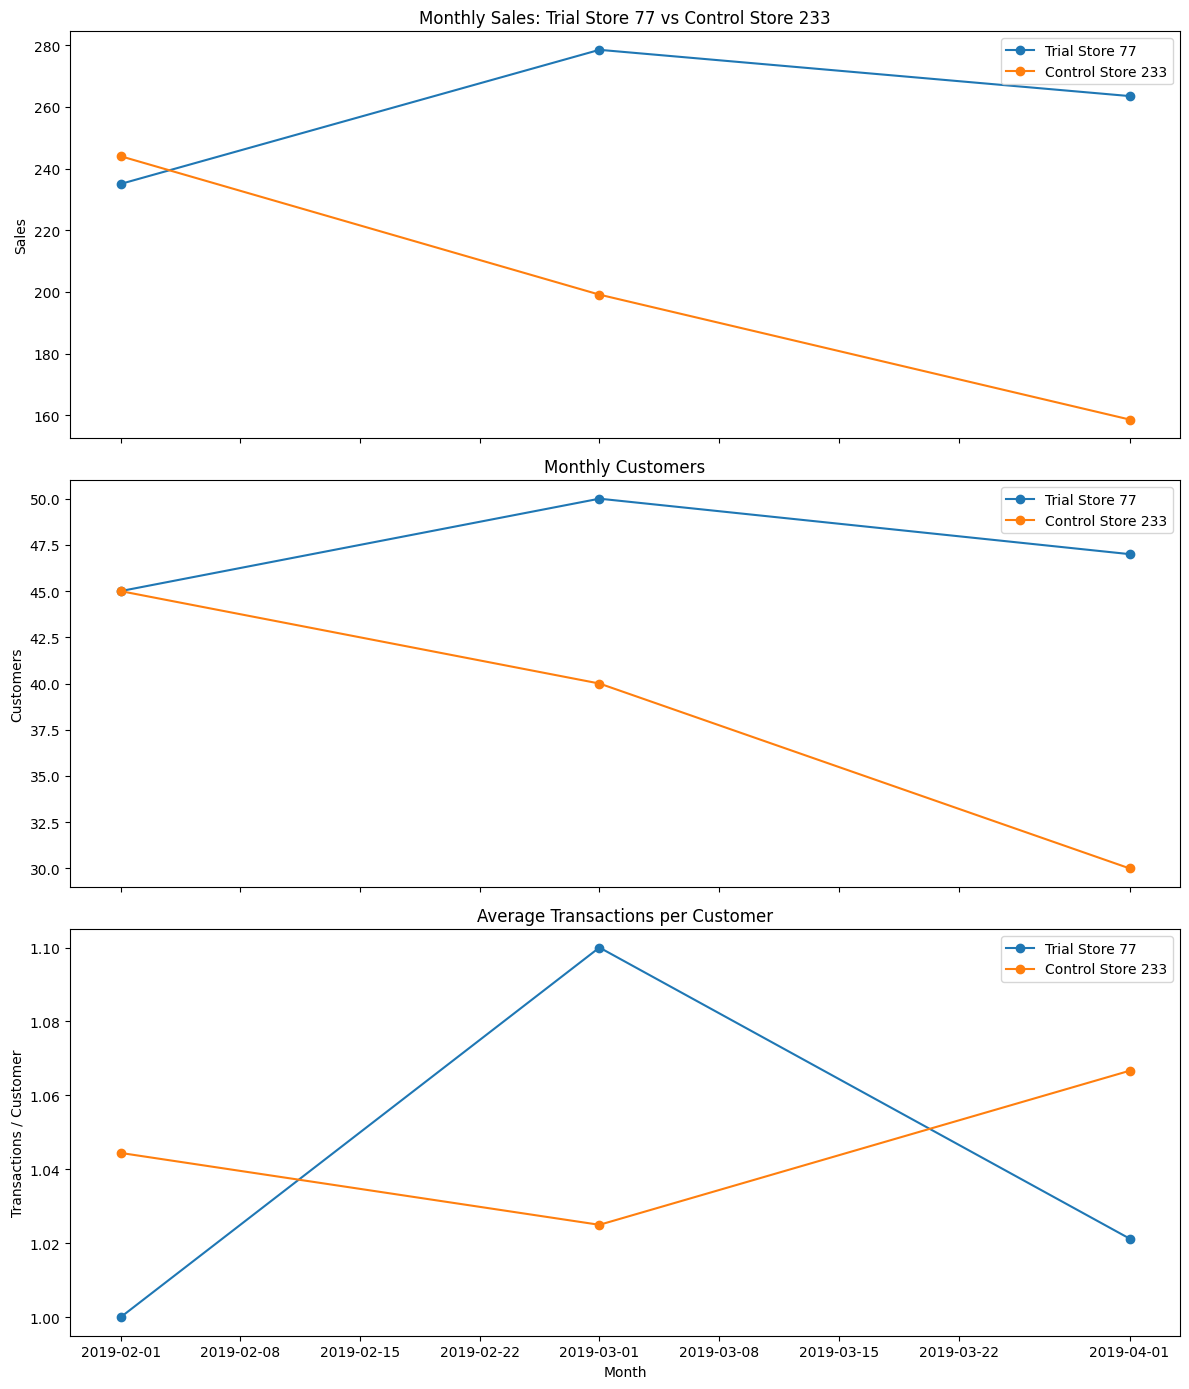

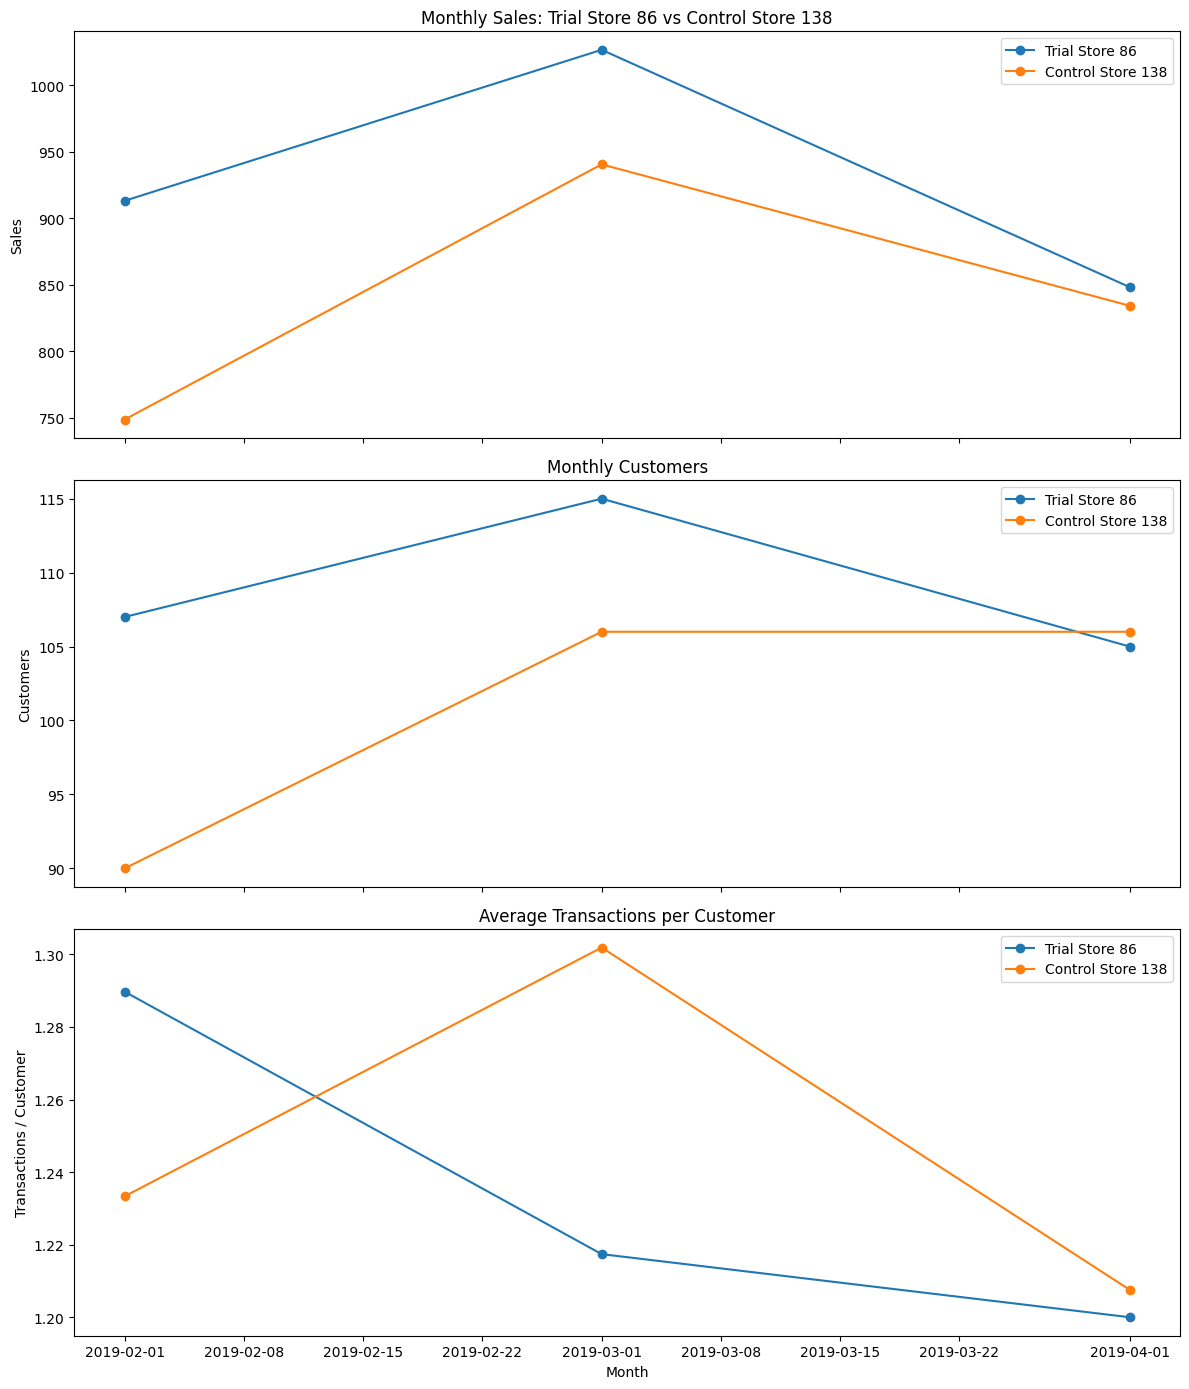

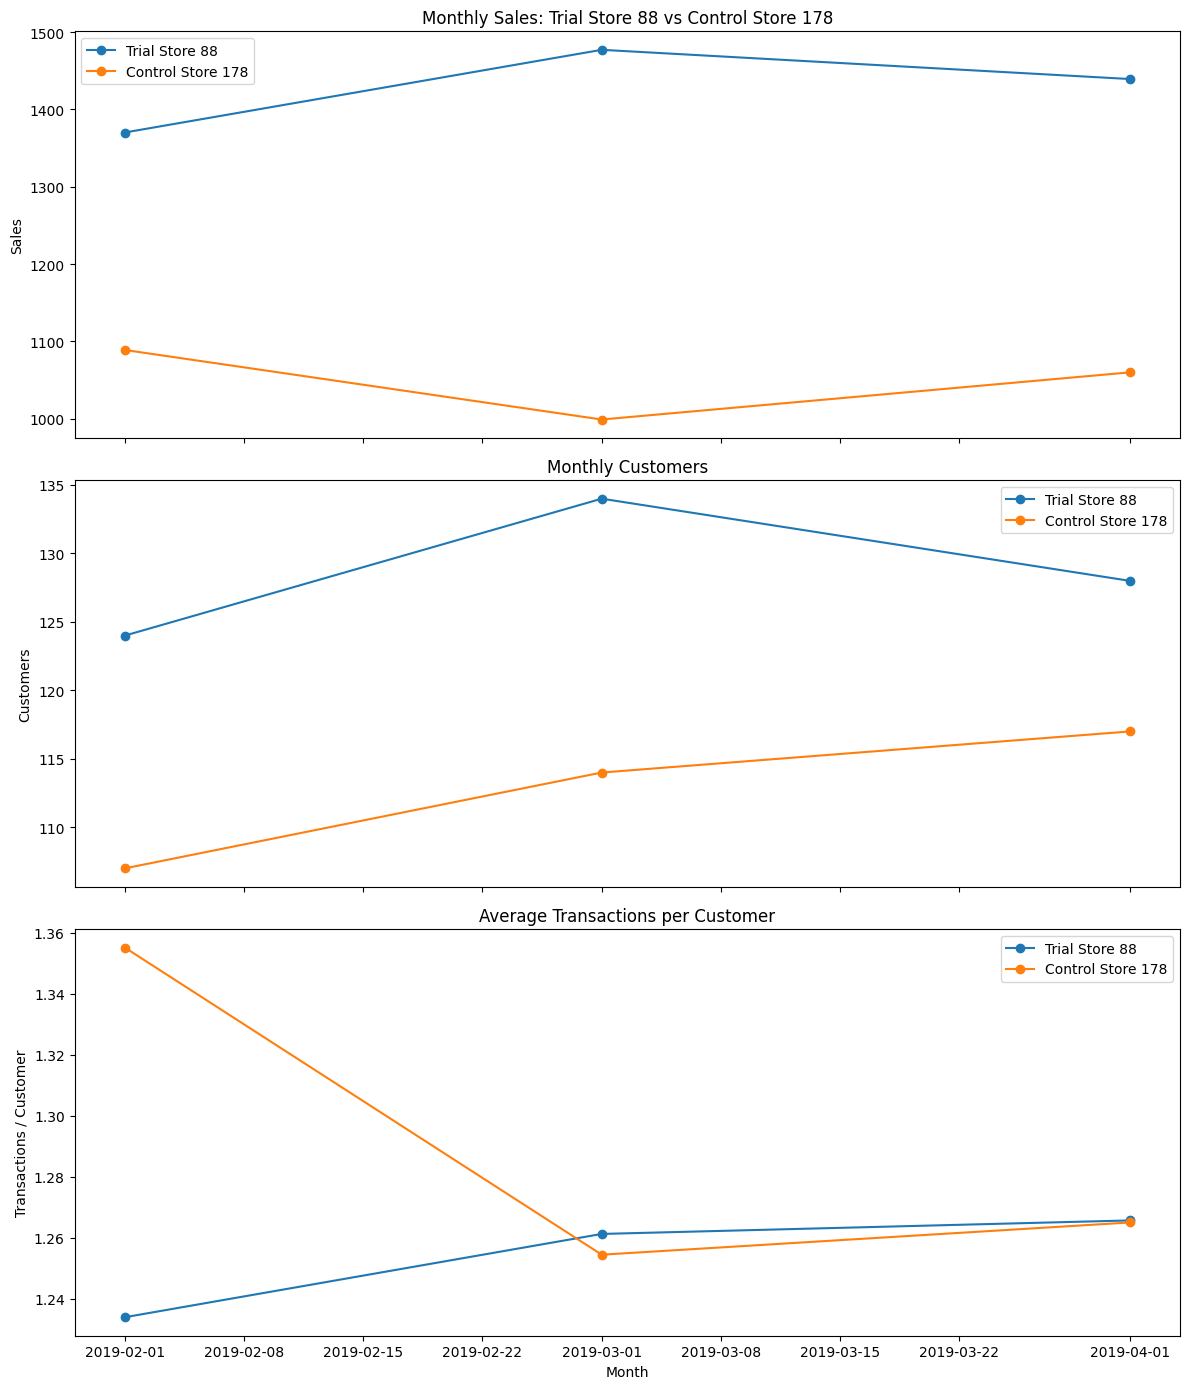

In [25]:
# =========================
# 11) PLOT EACH TRIAL VS CONTROL PAIR
# =========================
for trial_store in trial_stores:
    comp = all_comp_tables[trial_store]
    plot_trial_vs_control(comp, trial_store, control_map[trial_store])

In [16]:
# SIMPLE SUCCESS / FAIL INTERPRETATION
#   =========================
def interpret_row(row):
    if pd.isna(row["sales_p_value"]):
        return "Insufficient data for significance test"
    if row["sales_lift_pct_avg"] > 0 and row["sales_p_value"] < 0.05:
        return "Likely successful"
    elif row["sales_lift_pct_avg"] > 0:
        return "Positive uplift, but not statistically strong"
    else:
        return "No positive uplift"

results_df["interpretation"] = results_df.apply(interpret_row, axis=1)
results_df

,trial_store,control_store,trial_avg_sales,control_avg_sales,sales_lift_pct_avg,trial_avg_customers,control_avg_customers,customers_lift_pct_avg,trial_avg_txn_per_customer,control_avg_txn_per_customer,txn_per_customer_lift_pct_avg,sales_t_stat,sales_p_value,customers_t_stat,customers_p_value,txn_per_customer_t_stat,txn_per_customer_p_value,interpretation
0,77,233,259.000000,200.566667,29.134120,47.333333,38.333333,23.478261,1.040426,1.045370,-0.473023,1.693186,0.232498,1.824491,0.209634,-0.123703,0.912861,"Positive uplift, but not statistically strong"
1,86,138,929.400000,841.133333,10.493778,109.000000,100.666667,8.278146,1.235704,1.247589,-0.952674,2.029737,0.179516,1.600461,0.250637,-0.291833,0.797901,"Positive uplift, but not statistically strong"
2,88,178,1428.933333,1049.133333,36.201309,128.666667,112.666667,14.201183,1.253563,1.291494,-2.936996,6.678496,0.021693,6.047432,0.026271,-0.909473,0.459101,Likely successful


In [17]:
# FINAL SUMMARY TABLE
# =========================
summary_cols = [
    "trial_store", "control_store",
    "sales_lift_pct_avg", "customers_lift_pct_avg", "txn_per_customer_lift_pct_avg",
    "sales_p_value", "customers_p_value", "txn_per_customer_p_value",
    "interpretation"
]

final_summary = results_df[summary_cols].copy()
final_summary

,trial_store,control_store,sales_lift_pct_avg,customers_lift_pct_avg,txn_per_customer_lift_pct_avg,sales_p_value,customers_p_value,txn_per_customer_p_value,interpretation
0,77,233,29.134120,23.478261,-0.473023,0.232498,0.209634,0.912861,"Positive uplift, but not statistically strong"
1,86,138,10.493778,8.278146,-0.952674,0.179516,0.250637,0.797901,"Positive uplift, but not statistically strong"
2,88,178,36.201309,14.201183,-2.936996,0.021693,0.026271,0.459101,Likely successful


In [18]:
#  SAVE OUTPUTS
# =========================
output_dir = Path("quantium_task2_outputs")
output_dir.mkdir(exist_ok=True)

# Save summary CSV
final_summary.to_csv(output_dir / "task2_final_summary.csv", index=False)

# Save detailed monthly comparison tables for each trial store
with pd.ExcelWriter(output_dir / "task2_detailed_results.xlsx", engine="openpyxl") as writer:
    final_summary.to_excel(writer, sheet_name="Summary", index=False)
    for trial_store, comp in all_comp_tables.items():
        comp.to_excel(writer, sheet_name=f"Store_{trial_store}", index=False)

print(f"Files saved in: {output_dir.resolve()}")

Files saved in: E:\data analyst\QUANTUM\quantium_task2_outputs
